# Model Training — Prophet

Goal:
- Train a Prophet forecasting model per product
- Evaluate performance against Rolling-7 baseline
- Understand where Prophet helps and where it fails

In [57]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [58]:
FEATURE_PATH = "../data/processed/"
df = pd.read_csv(FEATURE_PATH + "features_ca1.csv", parse_dates=["date"])

C:\Users\HP\AppData\Local\Temp\ipykernel_4772\1088541024.py:2: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FEATURE_PATH + "features_ca1.csv", parse_dates=["date"])


In [59]:
df = df.dropna(subset=["lag_1", "rolling_mean_7"])

In [60]:
split_date = df["date"].quantile(0.8)

train_df = df[df["date"] <= split_date]
test_df  = df[df["date"] > split_date]

In [61]:
#For one item only

item_id = train_df["item_id"].iloc[0]

train_item = train_df[train_df["item_id"] == item_id][["date", "sales"]]
test_item  = test_df[test_df["item_id"] == item_id][["date", "sales"]]

train_item = train_item.rename(columns={"date": "ds", "sales": "y"})

In [62]:
item_id

'FOODS_1_001'

In [63]:
train_item

,ds,y
7,2011-02-05,2
8,2011-02-06,0
9,2011-02-07,0
10,2011-02-08,0
11,2011-02-09,0
...,...,...
1527,2015-04-05,2
1528,2015-04-06,0
1529,2015-04-07,0
1530,2015-04-08,1


In [64]:
prophet_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(train_item)

17:47:56 - cmdstanpy - INFO - Chain [1] start processing
17:47:56 - cmdstanpy - INFO - Chain [1] done processing


In [65]:
future = test_item[["date"]].rename(columns={"date": "ds"})
forecast = prophet_model.predict(future)

y_true = test_item["sales"].values
y_pred = forecast["yhat"].values

In [66]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_prophet, rmse_prophet = evaluate(y_true, y_pred)
mae_prophet, rmse_prophet

(0.8475017583764904, np.float64(1.0560705429293404))

In [67]:
baseline_item = test_df[test_df["item_id"] == item_id]

mae_roll7, rmse_roll7 = evaluate(
    baseline_item["sales"],
    baseline_item["rolling_mean_7"]
)

mae_roll7, rmse_roll7

(0.8113985751781027, np.float64(1.0719471311043285))

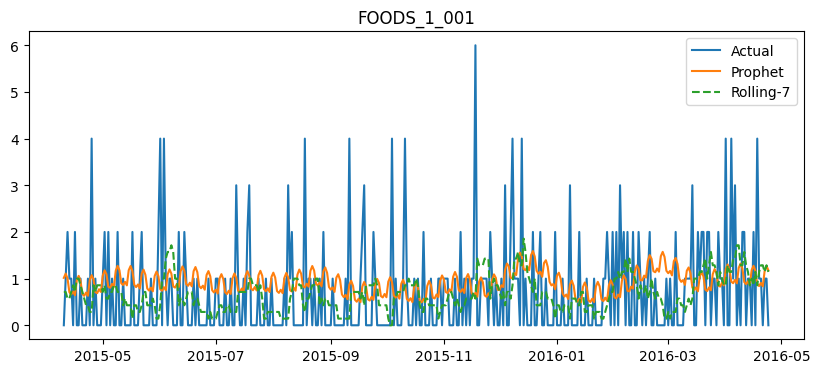

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(test_item["date"], y_true, label="Actual")
plt.plot(test_item["date"], y_pred, label="Prophet")
plt.plot(
    baseline_item["date"],
    baseline_item["rolling_mean_7"],
    label="Rolling-7",
    linestyle="--"
)
plt.legend()
plt.title(item_id)
plt.show()

# Product Segmentation

In [69]:
product_stats = (
    df.groupby("item_id")
      .agg(
          avg_sales=("sales", "mean"),
          std_sales=("sales", "std"),
          zero_ratio=("sales", lambda x: (x == 0).mean())
      )
      .reset_index()
)

In [70]:
def segment(row):
    if row["avg_sales"] >= 2 and row["zero_ratio"] < 0.3:
        return "smooth_high_volume"
    elif row["zero_ratio"] >= 0.5:
        return "intermittent"
    else:
        return "medium"

product_stats["segment"] = product_stats.apply(segment, axis=1)
product_stats["segment"].value_counts()

segment
intermittent          2217
medium                 573
smooth_high_volume     259
Name: count, dtype: int64

In [71]:
product_stats.head()

,item_id,avg_sales,std_sales,zero_ratio,segment
0,FOODS_1_001,0.783316,1.256481,0.564008,intermittent
1,FOODS_1_002,0.477440,0.804688,0.668940,intermittent
2,FOODS_1_003,0.832634,1.163669,0.528332,intermittent
3,FOODS_1_004,8.288038,8.868324,0.319517,medium
4,FOODS_1_005,1.155824,2.009782,0.539874,intermittent


In [72]:
good_items = product_stats[
    product_stats["segment"].isin(["smooth_high_volume", "medium"])
]["item_id"]

ml_df = df[df["item_id"].isin(good_items)]

In [73]:
good_items

3           FOODS_1_004
5           FOODS_1_006
10          FOODS_1_012
14          FOODS_1_016
16          FOODS_1_018
             ...       
2997    HOUSEHOLD_2_465
3002    HOUSEHOLD_2_470
3015    HOUSEHOLD_2_483
3042    HOUSEHOLD_2_510
3043    HOUSEHOLD_2_511
Name: item_id, Length: 832, dtype: object

In [74]:
import lightgbm as lgb

In [75]:
ml_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_1,event_name_2,event_type_2,snap_CA,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,is_weekend
5746,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_8,0,2011-02-05,11102,...,NaN,NaN,NaN,1,0.0,0.0,NaN,0.0,NaN,1
5747,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_9,0,2011-02-06,11102,...,Sporting,NaN,NaN,1,0.0,0.0,NaN,0.0,NaN,0
5748,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_10,0,2011-02-07,11102,...,NaN,NaN,NaN,1,0.0,0.0,NaN,0.0,NaN,0
5749,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_11,0,2011-02-08,11102,...,NaN,NaN,NaN,1,0.0,0.0,NaN,0.0,NaN,0
5750,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_12,0,2011-02-09,11102,...,NaN,NaN,NaN,1,0.0,0.0,NaN,0.0,NaN,0


In [76]:
good_items.head()

3     FOODS_1_004
5     FOODS_1_006
10    FOODS_1_012
14    FOODS_1_016
16    FOODS_1_018
Name: item_id, dtype: object

In [77]:
ml_df.shape

(1585792, 24)

In [78]:
feature_cols = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_14",
    "wday", "month"
]

target_col = "sales"

In [79]:
ml_df = ml_df.dropna(subset=feature_cols + [target_col])

In [80]:
split_date = ml_df["date"].quantile(0.8)

train_df = ml_df[ml_df["date"] <= split_date]
test_df  = ml_df[ml_df["date"] > split_date]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

In [81]:
model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 1264640, number of used features: 7
[LightGBM] [Info] Start training from score 3.504843


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [82]:
y_pred = model.predict(X_test)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_lgb, rmse_lgb = evaluate(y_test, y_pred)
mae_lgb, rmse_lgb

(1.893285243548349, np.float64(3.3891994241247763))

- Lightgbm MAE : 1.893285243548349
- Lightgbm RMSE : 3.3891994241247763

This is Lighgbm performance without any Tuning.

Prophet :
- MAE : 0.8475017583764904
- RMSE : 1.0560705429293404

Baseline :
- MAE: 0.8113985751781027
- RMSE: 1.0719471311043285

In [83]:
prices = pd.read_csv("../data/raw/sell_prices.csv")

ml_df = ml_df.merge(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

In [84]:
ml_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_name_2,event_type_2,snap_CA,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,is_weekend,sell_price
0,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_15,0,2011-02-12,11103,...,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,1,NaN
1,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_16,0,2011-02-13,11103,...,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0,NaN
2,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_17,0,2011-02-14,11103,...,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0,NaN
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_18,0,2011-02-15,11103,...,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0,NaN
4,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_19,0,2011-02-16,11103,...,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0,NaN


In [85]:
ml_df["sell_price"].isna().mean()

np.float64(0.04317049459229554)

In [86]:
ml_df = ml_df.sort_values(["item_id", "date"])

ml_df["price_change"] = (
    ml_df.groupby("item_id")["sell_price"]
    .pct_change()
)

ml_df["price_change"] = ml_df["price_change"].fillna(0)

C:\Users\HP\AppData\Local\Temp\ipykernel_4772\2508907150.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


In [87]:
ml_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_2,snap_CA,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,is_weekend,sell_price,price_change
0,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_15,0,2011-02-12,11103,...,NaN,0,0.0,0.0,0.0,0.0,0.0,1,NaN,0.0
1,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_16,0,2011-02-13,11103,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0,NaN,0.0
2,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_17,0,2011-02-14,11103,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0,NaN,0.0
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_18,0,2011-02-15,11103,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0,NaN,0.0
4,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_19,0,2011-02-16,11103,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0,NaN,0.0


In [88]:
item_stats = (
    ml_df.groupby("item_id")
    .agg(
        item_mean_sales=("sales", "mean"),
        item_zero_ratio=("sales", lambda x: (x == 0).mean())
    )
    .reset_index()
)

ml_df = ml_df.merge(item_stats, on="item_id", how="left")

In [89]:
ml_df["sales_norm"] = (
    ml_df["sales"] / ml_df["item_mean_sales"]
)

In [90]:
feature_cols = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_14",
    "sell_price", "price_change",
    "wday", "month",
    "item_mean_sales", "item_zero_ratio"
]

target_col = "sales_norm"

ml_df = ml_df.dropna(subset=feature_cols + [target_col])

In [91]:
split_date = ml_df["date"].quantile(0.8)

train_df = ml_df[ml_df["date"] <= split_date]
test_df  = ml_df[ml_df["date"] > split_date]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

In [92]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1713
[LightGBM] [Info] Number of data points in the train set: 1209744, number of used features: 11
[LightGBM] [Info] Start training from score 1.054873
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [99]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(lgb_model, "../models/lightgbm_medium_ca1.pkl")

['../models/lightgbm_medium_ca1.pkl']

In [93]:
y_pred_norm = lgb_model.predict(X_test)

y_pred = y_pred_norm * test_df["item_mean_sales"].values
y_true = test_df["sales"].values

In [94]:
mae_lgb, rmse_lgb = evaluate(y_true, y_pred)

mae_roll7, rmse_roll7 = evaluate(
    y_true,
    test_df["rolling_mean_7"]
)


In [95]:
mae_lgb, rmse_lgb

(1.901236534133109, np.float64(3.4219888833657155))

In [96]:
mae_roll7, rmse_roll7

(2.003451094360185, np.float64(3.68981871259383))

In [97]:
product_stats.head()

,item_id,avg_sales,std_sales,zero_ratio,segment
0,FOODS_1_001,0.783316,1.256481,0.564008,intermittent
1,FOODS_1_002,0.477440,0.804688,0.668940,intermittent
2,FOODS_1_003,0.832634,1.163669,0.528332,intermittent
3,FOODS_1_004,8.288038,8.868324,0.319517,medium
4,FOODS_1_005,1.155824,2.009782,0.539874,intermittent


In [98]:
OUTPUT_PATH = "../data/processed/"

product_stats.to_csv(
    OUTPUT_PATH + "product_stats_ca1.csv",
    index=False
)